##############################################################
#  MACHINE LEARNING ANALYSIS FOR diabetes
##############################################################
## About this project :-

The objective of this project is to classify whether someone has diabetes or not.
Dataset consists of several Medical Variables(Independent) and one Outcome Variable(Dependent)

## About the Dataset:- 
[https://www.kaggle.com/datasets/hosammhmdali/diabetes-dataset/data]

Pregnancies :- Number of times a woman has been pregnant
Glucose :- Plasma Glucose concentration of 2 hours in an oral glucose tolerance test
BloodPressure :- Diastollic Blood Pressure (mm hg)
SkinThickness :- Triceps skin fold thickness(mm)
Insulin :- 2 hour serum insulin(mu U/ml)
BMI :- Body Mass Index ((weight in kg/height in m)^2)
Age :- Age(years)
DiabetesPedigreeFunction :-scores likelihood of diabetes based on family history

## Outcome :- 

0 (doesn't have diabetes) or 1 (has diabetes)

## Import Required Libraries

In [12]:
# Data manipulation
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Ignore warnings
import warnings
warnings.filterwarnings("ignore")

# Machine Learning
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.impute import SimpleImputer

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    auc
)

# Models
from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC

from imblearn.over_sampling import RandomOverSampler
from imblearn.under_sampling import RandomUnderSampler
from imblearn.over_sampling import SMOTE


plt.style.use('fivethirtyeight')

import warnings
warnings.filterwarnings('ignore')

# Save Model
import joblib


 ##############################################################
## LOAD DATA
##############################################################

In [13]:
df = pd.read_csv ('/kaggle/input/datasets/ghadaelfeki/diabetes-prediction-ml-project-4-gh/diabetes.csv')

## Display Basic Information

In [14]:
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [15]:
df.tail()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
764,2,122,70,27,0,36.8,0.340,27,0
765,5,121,72,23,112,26.2,0.245,30,0
766,1,126,60,0,0,30.1,0.349,47,1
767,1,93,70,31,0,30.4,0.315,23,0
768,0,123,77,0,1,36.3,0.252,55,1


In [16]:
df.shape

(769, 9)

In [17]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 769 entries, 0 to 768
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               769 non-null    int64  
 1   Glucose                   769 non-null    int64  
 2   BloodPressure             769 non-null    int64  
 3   SkinThickness             769 non-null    int64  
 4   Insulin                   769 non-null    int64  
 5   BMI                       769 non-null    float64
 6   DiabetesPedigreeFunction  769 non-null    float64
 7   Age                       769 non-null    int64  
 8   Outcome                   769 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.2 KB


In [18]:
df.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,769.000000,769.000000,769.000000,769.000000,769.000000,769.000000,769.000000,769.000000,769.000000
mean,3.840052,120.897269,69.115735,20.509753,79.697009,31.998179,0.471590,33.269181,0.349805
std,3.370237,31.951886,19.345296,15.959020,115.203999,7.880557,0.331208,11.778737,0.477219
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.244000,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,29.000000,32.000000,0.371000,29.000000,0.000000
75%,6.000000,140.000000,80.000000,32.000000,127.000000,36.600000,0.626000,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


##############################################################
## Check DUPLICATES
##############################################################

In [19]:
df.duplicated().sum()

np.int64(0)

##############################################################
## CHECK MISSING VALUES
##############################################################

In [20]:
df.isnull().sum()

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

In [21]:
df.columns

Index(['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin',
       'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome'],
      dtype='object')

### Exploratory Data Analysis (EDA)
## Class Distribution

Outcome
0    500
1    269
Name: count, dtype: int64


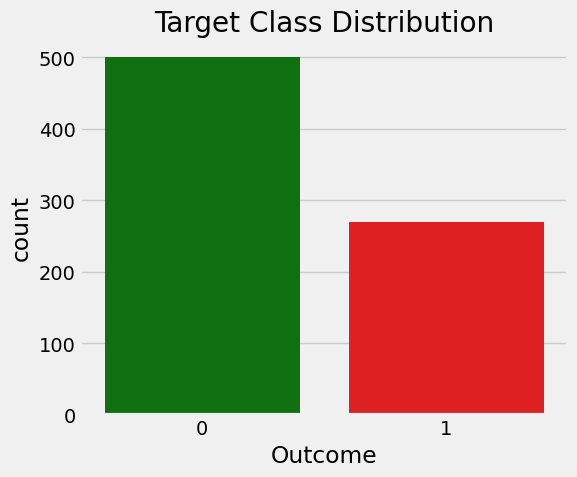

In [23]:
plt.figure(figsize=(6,5))

sns.countplot(
    data=df,
    x="Outcome",
    palette=["g", "r"]
)

plt.title("Target Class Distribution")
plt.tight_layout()

print(df["Outcome"].value_counts())

In [24]:
#Finding Missing Values in Data
print(df[df['BloodPressure']==0].shape[0])
print(df[df['Glucose']==0].shape[0])
print(df[df['SkinThickness']==0].shape[0])
print(df[df['Insulin']==0].shape[0])
print(df[df['BMI']==0].shape[0])

35
5
228
374
11


## ## Numerical Feature Histograms

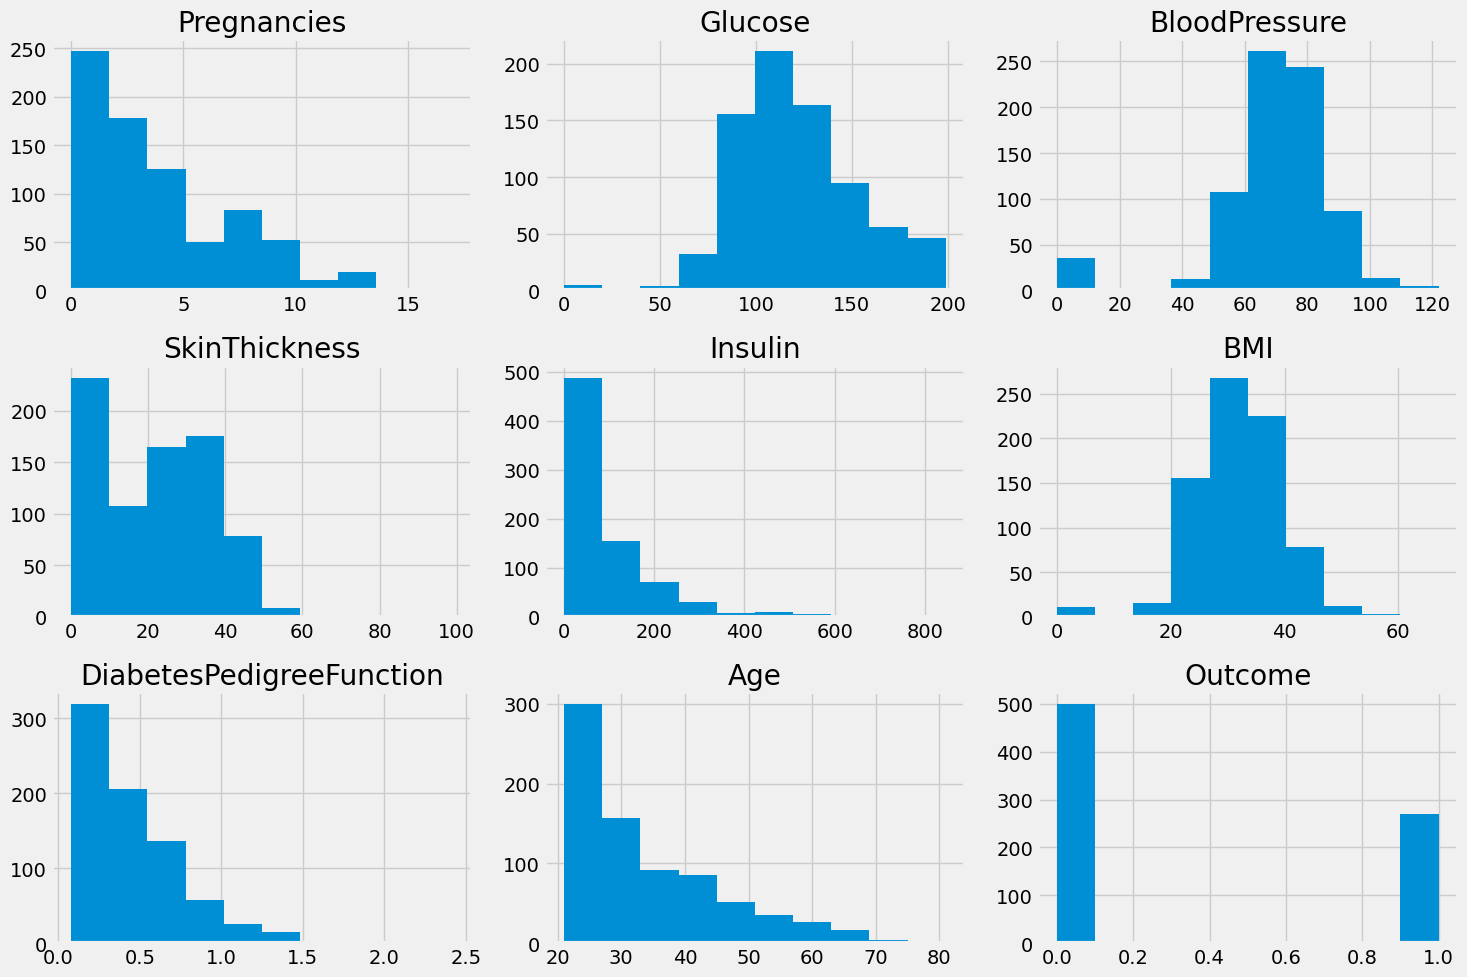

In [26]:
# Understanding the Shape and Distribution of Data to Complete the Missing Data
df.hist(bins=10,figsize=(15,10))
plt.tight_layout()

plt.show()

## Pairplot

### Since plotting every variable is clusttered, use only the most informative numeric features.
This allows you to visually compare feature relationships across the outcome classes.

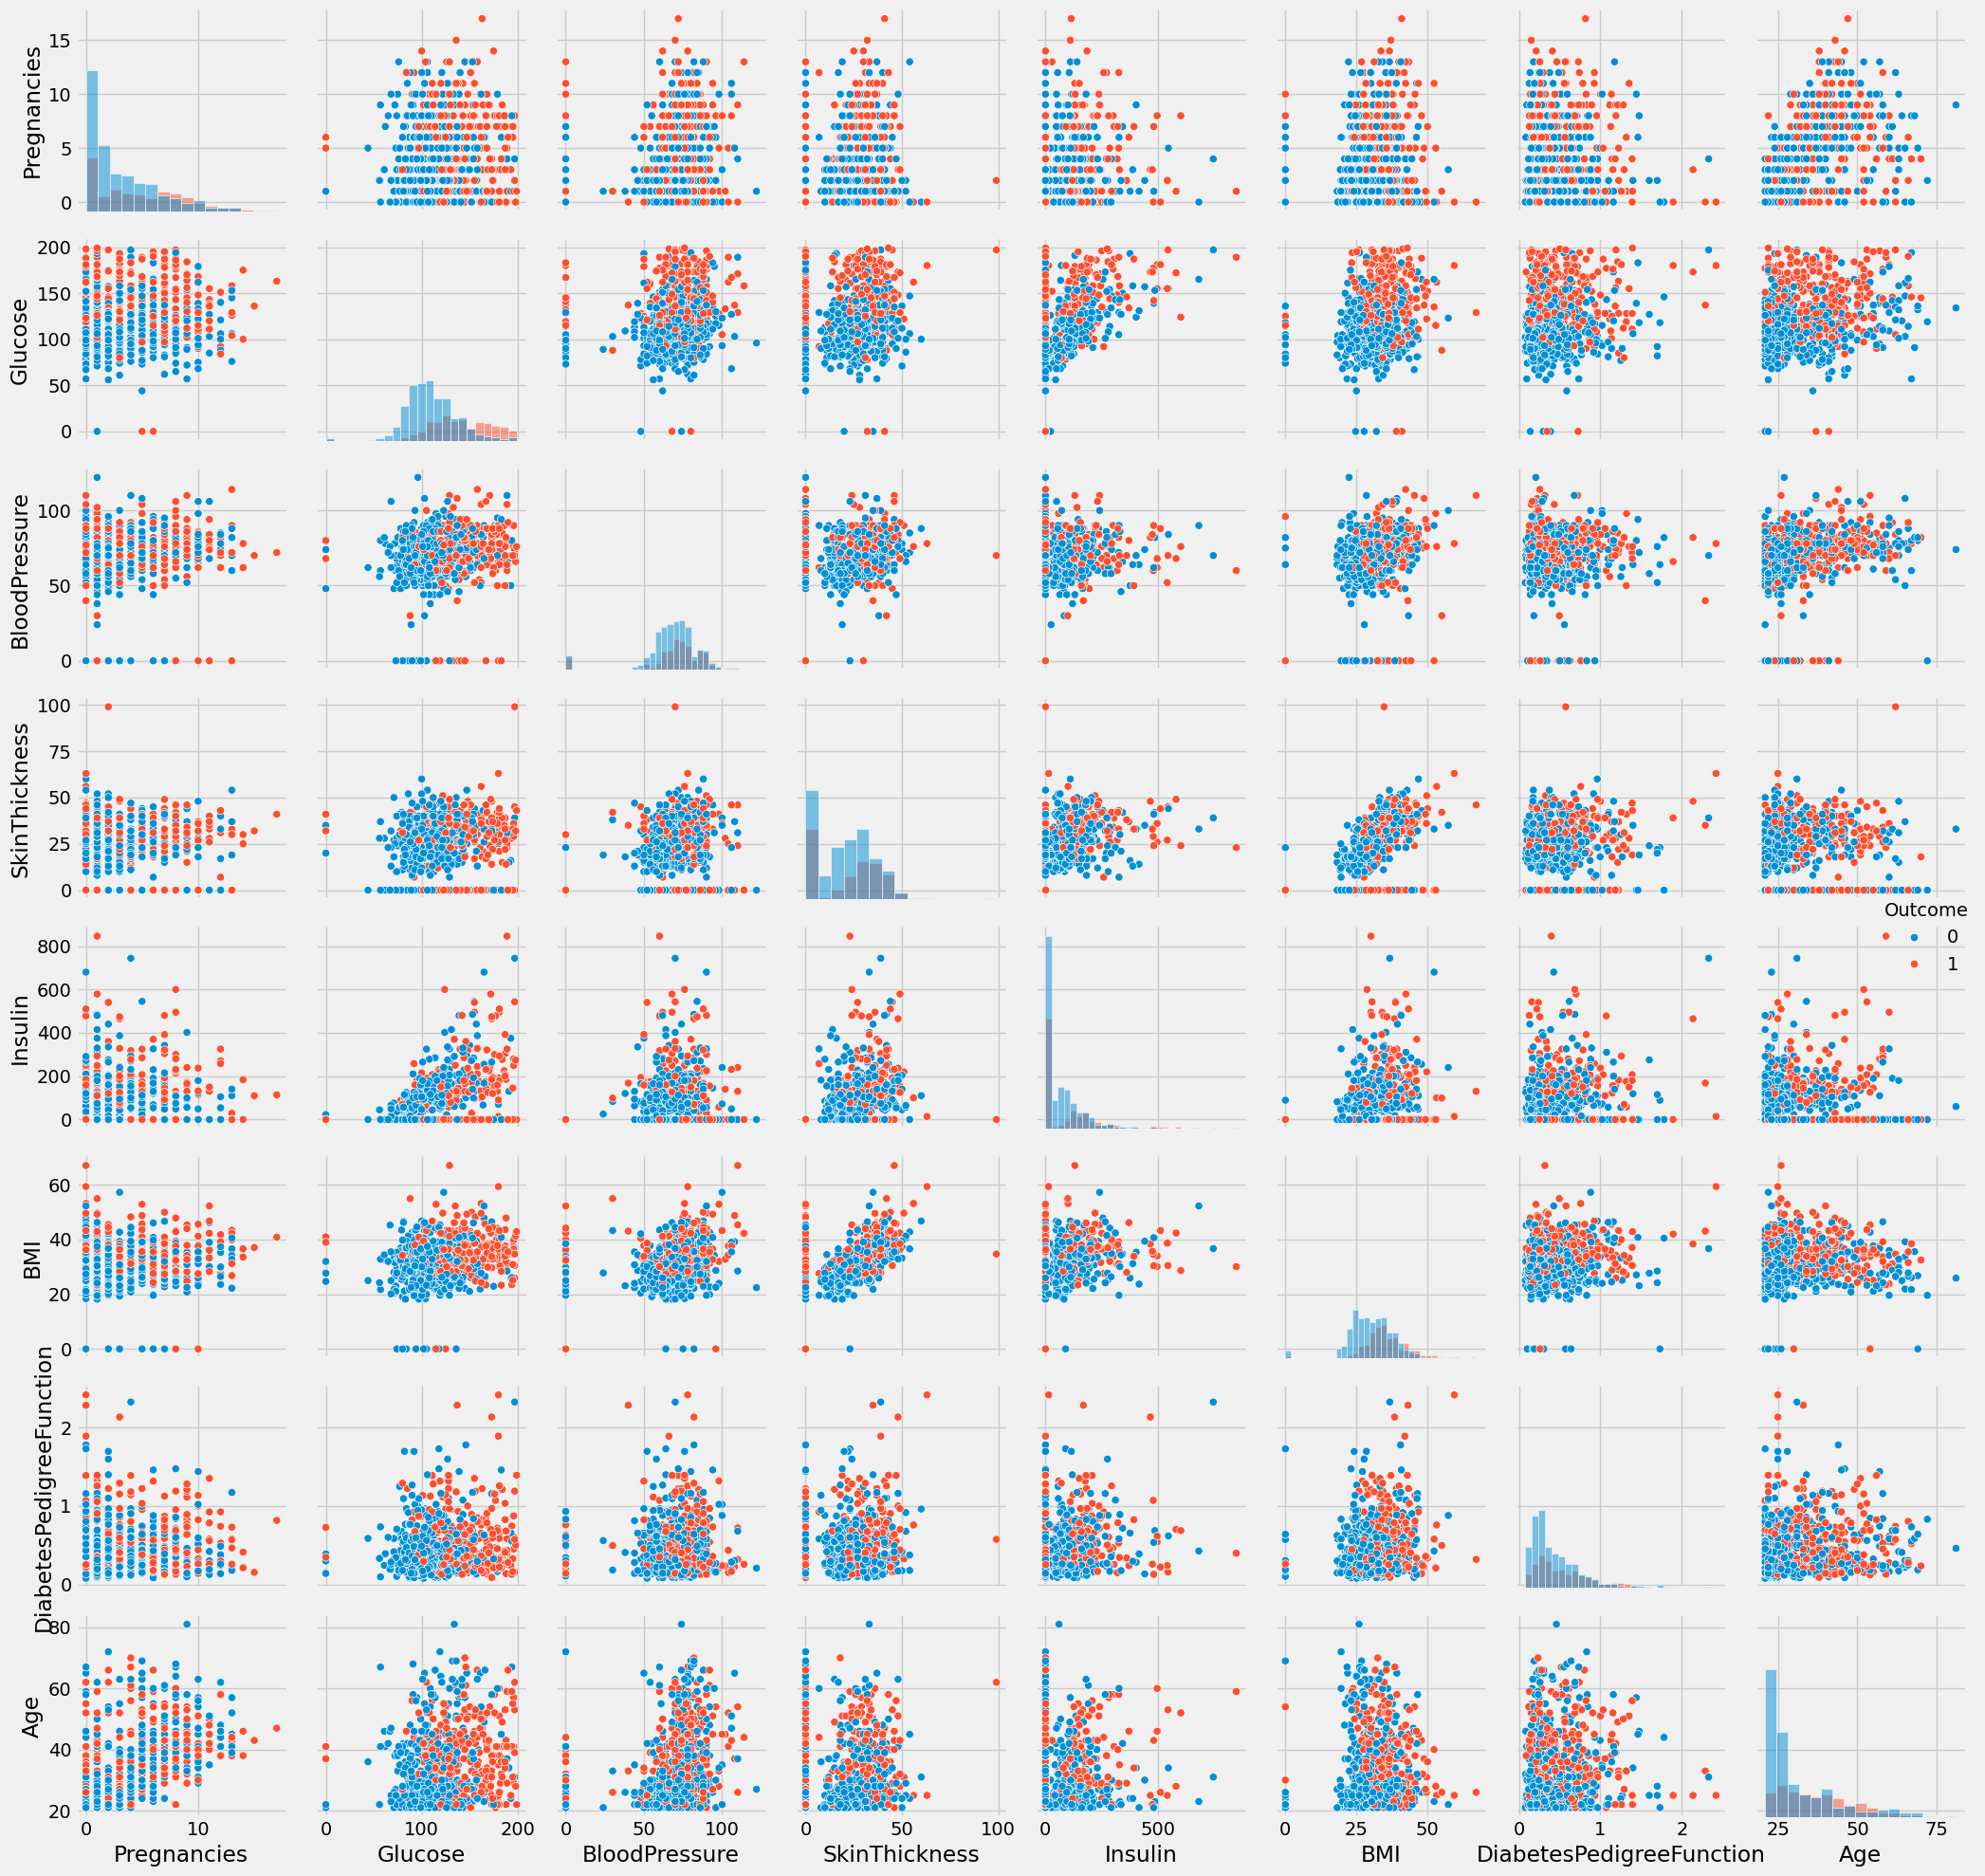

In [27]:
selected_features = [
   'Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin',
       'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome'
]

sns.pairplot(
    df[selected_features],
    hue="Outcome",
    diag_kind="hist"
)
plt.tight_layout()

plt.show()

## Boxplots for Outlier Detection
Boxplots highlight observations outside the whiskers, which may represent potential outliers.

In [28]:
numeric_cols = df.select_dtypes(include=[np.number]).columns

print(numeric_cols)

Index(['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin',
       'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome'],
      dtype='object')


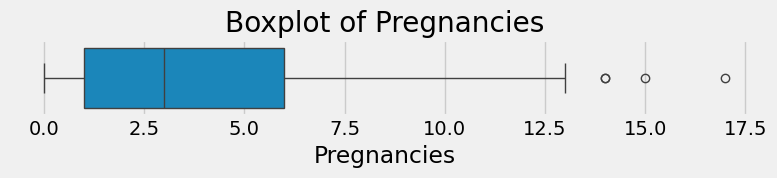

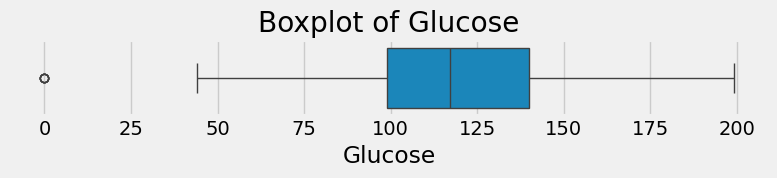

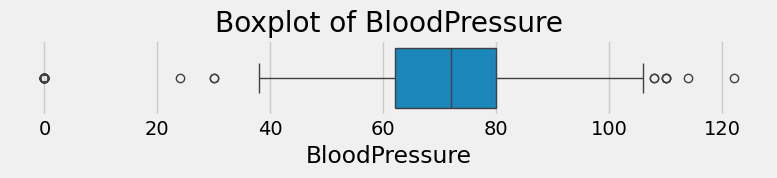

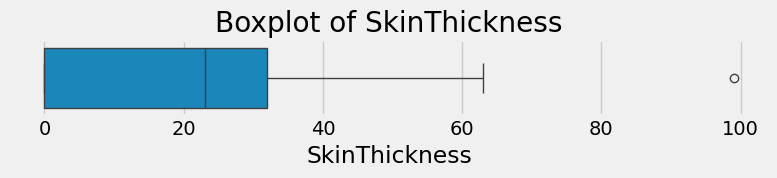

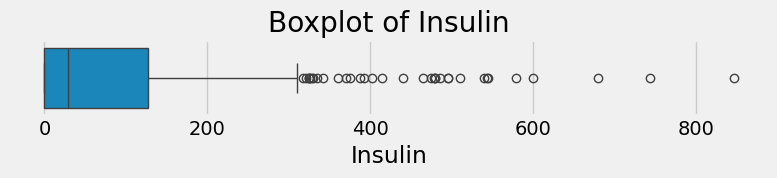

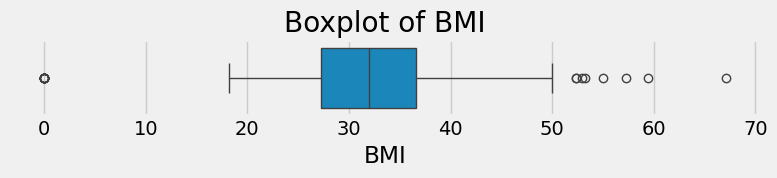

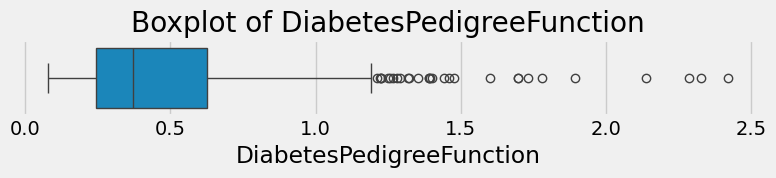

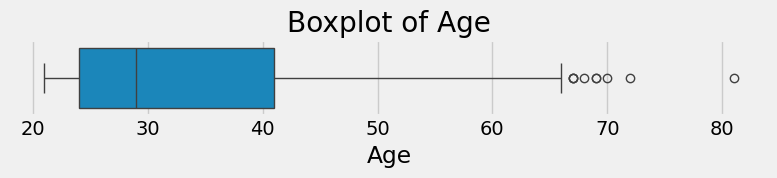

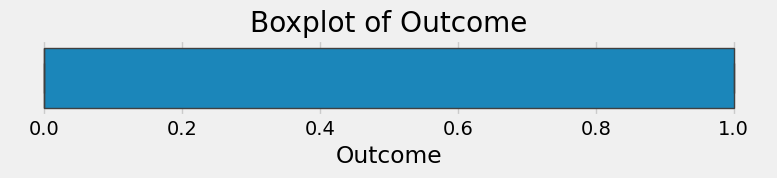

In [29]:
for column in numeric_cols:

    plt.figure(figsize=(8,2))

    sns.boxplot(x=df[column])

    plt.title(f"Boxplot of {column}")

    plt.tight_layout()

plt.show()

##  IQR-Based Outlier Detection

In [30]:
print("="*60)
print("Outlier Summary")

for col in numeric_cols:

    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)

    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = df[(df[col] < lower) | (df[col] > upper)]

    print(f"{col}: {len(outliers)} outliers")

Outlier Summary
Pregnancies: 4 outliers
Glucose: 5 outliers
BloodPressure: 45 outliers
SkinThickness: 1 outliers
Insulin: 35 outliers
BMI: 19 outliers
DiabetesPedigreeFunction: 29 outliers
Age: 9 outliers
Outcome: 0 outliers


## ## Outlier Removal
Consider removing outliers only if they are likely to be measurement errors; in clinical datasets, extreme values can be clinically meaningful.


In [31]:
clean_df = df.copy()

for col in numeric_cols:

    Q1 = clean_df[col].quantile(0.25)
    Q3 = clean_df[col].quantile(0.75)

    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    clean_df = clean_df[
        (clean_df[col] >= lower) &
        (clean_df[col] <= upper)
    ]

print("Original Shape:", df.shape)
print("Clean Shape:", clean_df.shape)

Original Shape: (769, 9)
Clean Shape: (641, 9)


In [38]:
df['Glucose']=df['Glucose'].replace(0,df['Glucose'].mean())#normal distribution
df['BloodPressure']=df['BloodPressure'].replace(0,df['BloodPressure'].mean())#normal distribution
df['SkinThickness']=df['SkinThickness'].replace(0,df['SkinThickness'].median())#skewed distribution
df['Insulin']=df['Insulin'].replace(0,df['Insulin'].median())#skewed distribution
df['BMI']=df['BMI'].replace(0,df['BMI'].median())#skewed distribution

In [35]:
df.corr()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
Pregnancies,1.000000,0.127791,0.208204,0.033233,-0.055290,0.020693,-0.032500,0.539932,0.219418
Glucose,0.127791,1.000000,0.219663,0.172310,0.355571,0.231453,0.137029,0.266111,0.492388
BloodPressure,0.208204,0.219663,1.000000,0.152166,-0.023373,0.281433,0.000023,0.326918,0.163478
SkinThickness,0.033233,0.172310,0.152166,1.000000,0.238964,0.546419,0.143321,0.053256,0.187976
Insulin,-0.055290,0.355571,-0.023373,0.238964,1.000000,0.188109,0.179074,-0.018908,0.145735
BMI,0.020693,0.231453,0.281433,0.546419,0.188109,1.000000,0.152948,0.027028,0.312801
DiabetesPedigreeFunction,-0.032500,0.137029,0.000023,0.143321,0.179074,0.152948,1.000000,0.031882,0.172406
Age,0.539932,0.266111,0.326918,0.053256,-0.018908,0.027028,0.031882,1.000000,0.240816
Outcome,0.219418,0.492388,0.163478,0.187976,0.145735,0.312801,0.172406,0.240816,1.000000


## ## Correlation Heatmap
This heatmap helps identify highly correlated numerical variables, which can reveal redundancy or multicollinearity before modeling.

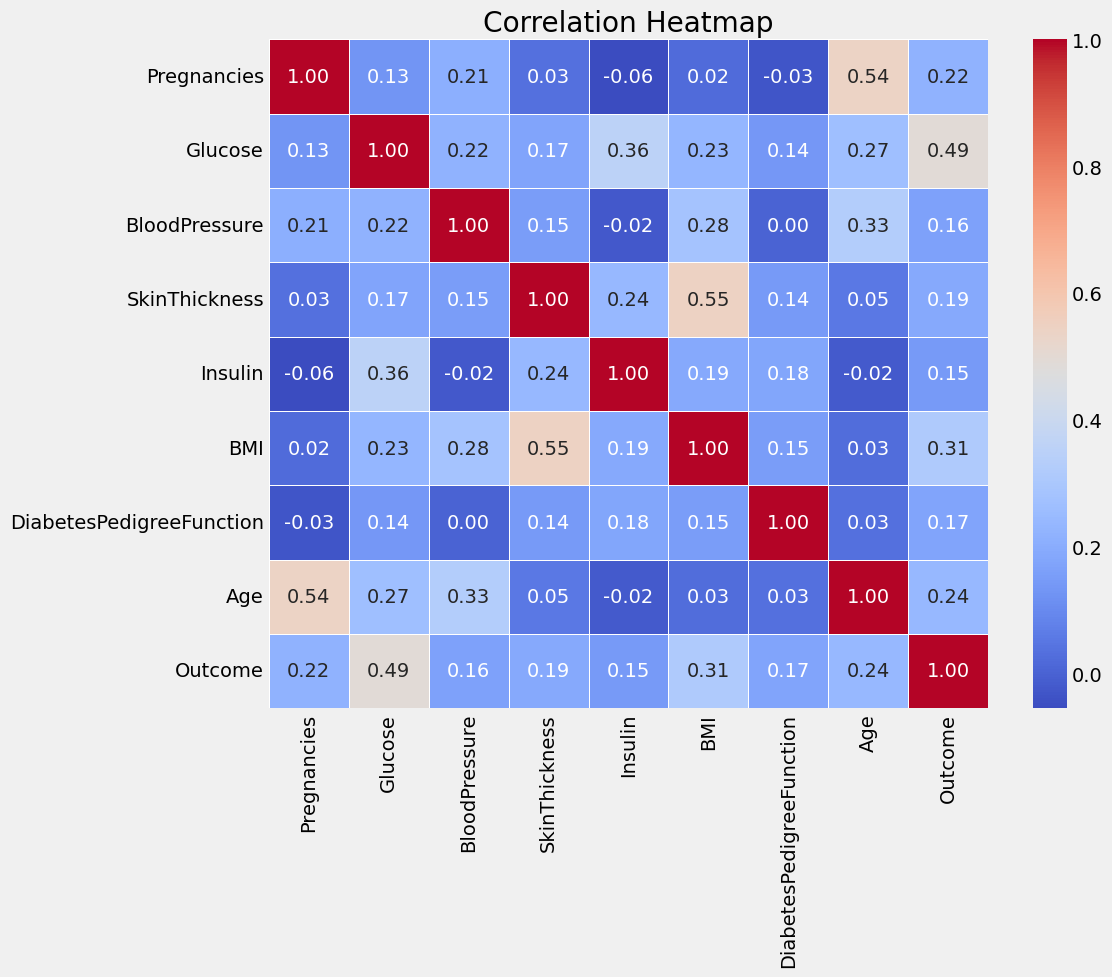

In [39]:
plt.figure(figsize=(12,10))

corr = df.corr()

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    linewidths=0.5,
    fmt=".2f"
)

plt.title("Correlation Heatmap")
plt.tight_layout()

plt.show()

## Identify the Target Variable

In [40]:
possible_targets = [
    'diagnosis',
    'Diagnosis',
    'target',
    'Target',
    'Class',
    'class',
    'Outcome',
    'Label'
]
target = None

for col in possible_targets:
    if col in df.columns:
        target = col
        break

if target is None:
    target = df.columns[-1]

print("\nTarget Column:", target)



Target Column: Outcome


In [41]:
target = "Outcome"
print(df[target].value_counts())

Outcome
0    500
1    269
Name: count, dtype: int64


In [43]:
data=df.drop('Insulin',axis=1)

## Prepare Data

In [50]:
X = df.drop("Outcome", axis=1)

y = df["Outcome"]


## Feature Scaling

In [51]:
scaler = StandardScaler()

X = scaler.fit_transform(X)

## Train-Test Split

In [57]:
X_train, X_test, y_train, y_test = train_test_split(

    X,

    y,

    test_size=0.2,

    random_state=42,

    stratify=y
)

## SMOTE

In [58]:
from imblearn.over_sampling import SMOTE

sm = SMOTE(random_state=42)

X_train, y_train = sm.fit_resample(
    X_train,
    y_train
)

## Train Models

In [61]:
models = {

    "Logistic Regression": LogisticRegression(),

    "Decision Tree": DecisionTreeClassifier(random_state=42),

    "Random Forest": RandomForestClassifier(random_state=42),

    "SVM": SVC(probability=True),

    "KNN": KNeighborsClassifier(),

    "Gradient Boosting": GradientBoostingClassifier(random_state=42)

}

## Evaluate Models

In [71]:
results = []

for name, model in models.items():
    print(f"Training {name}...")
    
    # 1. Fit the model
    model.fit(X_train, y_train)
    pred = model.predict(X_test)
    
    # 2. Safely get probabilities if available
    try:
        if hasattr(model, "predict_proba"):
            prob = model.predict_proba(X_test)[:, 1]
            # Use multi_class handling if y has more than 2 unique values
            if len(set(y_test)) > 2:
                prob = model.predict_proba(X_test)
                roc_val = roc_auc_score(y_test, prob, multi_class='ovr')
            else:
                roc_val = roc_auc_score(y_test, prob)
        else:
            roc_val = "N/A"
    except Exception as e:
        roc_val = "N/A"

    # 3. Safely calculate metrics (supports binary and multi-class)
    avg_method = 'binary' if len(set(y_test)) == 2 else 'macro'
    
    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, pred),
        "Precision": precision_score(y_test, pred, average=avg_method),
        "Recall": recall_score(y_test, pred, average=avg_method),
        "F1": f1_score(y_test, pred, average=avg_method),
        "ROC": roc_val
    })

# Convert to DataFrame and print
results_df = pd.DataFrame(results)
print("\nModel Evaluation Results:")
print(results_df.sort_values("Accuracy", ascending=False))

Training Logistic Regression...
Training Decision Tree...
Training Random Forest...
Training SVM...
Training KNN...
Training Gradient Boosting...

Model Evaluation Results:
                 Model  Accuracy  Precision    Recall        F1  ROC
5    Gradient Boosting  0.785714   0.666667  0.777778  0.717949  N/A
3                  SVM  0.772727   0.637681  0.814815  0.715447  N/A
2        Random Forest  0.766234   0.645161  0.740741  0.689655  N/A
1        Decision Tree  0.753247   0.653846  0.629630  0.641509  N/A
4                  KNN  0.733766   0.597015  0.740741  0.661157  N/A
0  Logistic Regression  0.727273   0.596774  0.685185  0.637931  N/A


## Confusion Matrix

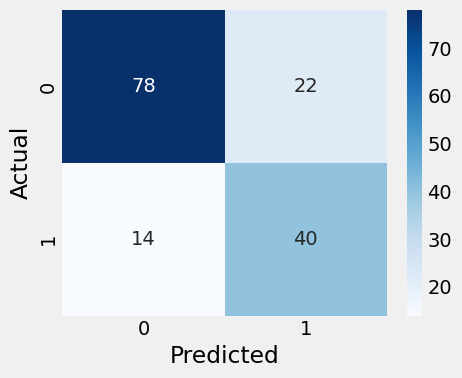

In [72]:
best = RandomForestClassifier(random_state=42)

best.fit(X_train,y_train)

pred = best.predict(X_test)

cm = confusion_matrix(y_test,pred)

plt.figure(figsize=(5,4))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.tight_layout()

plt.show()

## ROC Curve

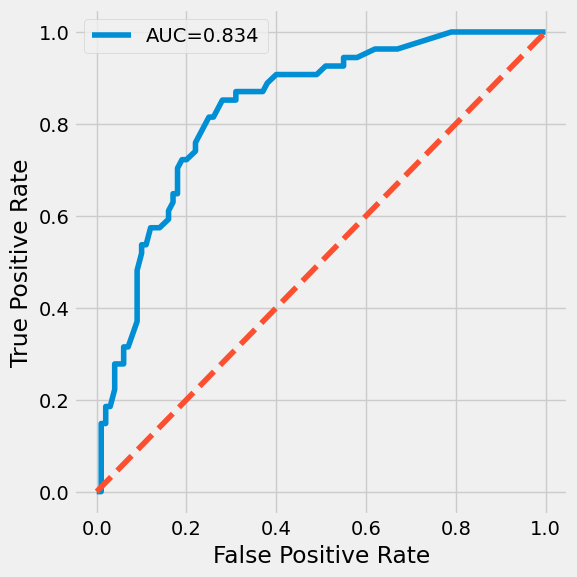

In [73]:
prob = best.predict_proba(X_test)[:,1]

fpr,tpr,_ = roc_curve(y_test,prob)

roc = auc(fpr,tpr)

plt.figure(figsize=(6,6))

plt.plot(fpr,tpr,label=f"AUC={roc:.3f}")

plt.plot([0,1],[0,1],'--')

plt.xlabel("False Positive Rate")

plt.ylabel("True Positive Rate")

plt.legend()

plt.tight_layout()

plt.show()

## Feature Importance

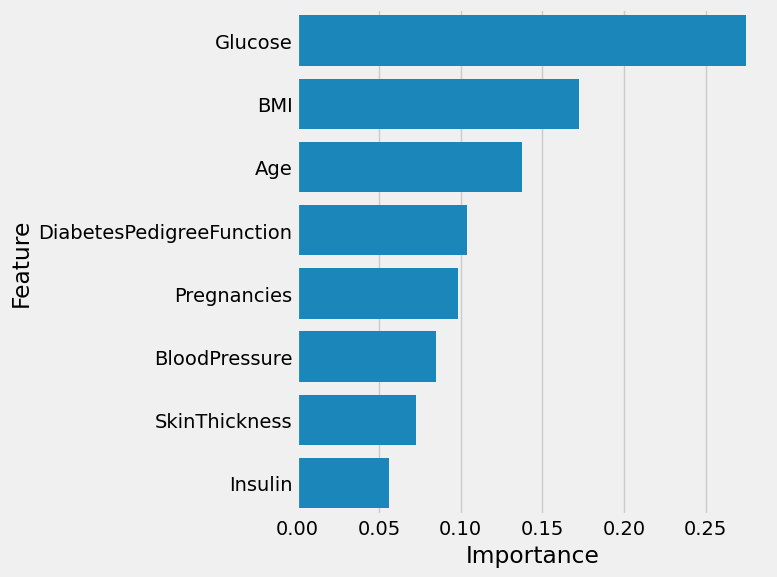

In [74]:
importance = pd.DataFrame({

    "Feature":df.columns[:-1],

    "Importance":best.feature_importances_

})

importance = importance.sort_values(

    "Importance",

    ascending=False

)

plt.figure(figsize=(8,6))

sns.barplot(

    data=importance,

    x="Importance",

    y="Feature"

)

plt.tight_layout()

plt.show()

## Cross Validation

In [75]:
scores = cross_val_score(

    best,

    X,

    y,

    cv=10

)

print(scores)

print(scores.mean())

[0.68831169 0.76623377 0.77922078 0.66233766 0.7012987  0.80519481
 0.80519481 0.83116883 0.66233766 0.78947368]
0.7490772385509228


## Hyperparameter Tuning

In [76]:
params = {

    "n_estimators":[100,200,300],

    "max_depth":[5,10,None],

    "min_samples_split":[2,5,10]

}

grid = GridSearchCV(

    RandomForestClassifier(random_state=42),

    params,

    cv=5,

    scoring="accuracy",

    n_jobs=-1

)

grid.fit(X_train,y_train)

print(grid.best_params_)

{'max_depth': None, 'min_samples_split': 2, 'n_estimators': 100}


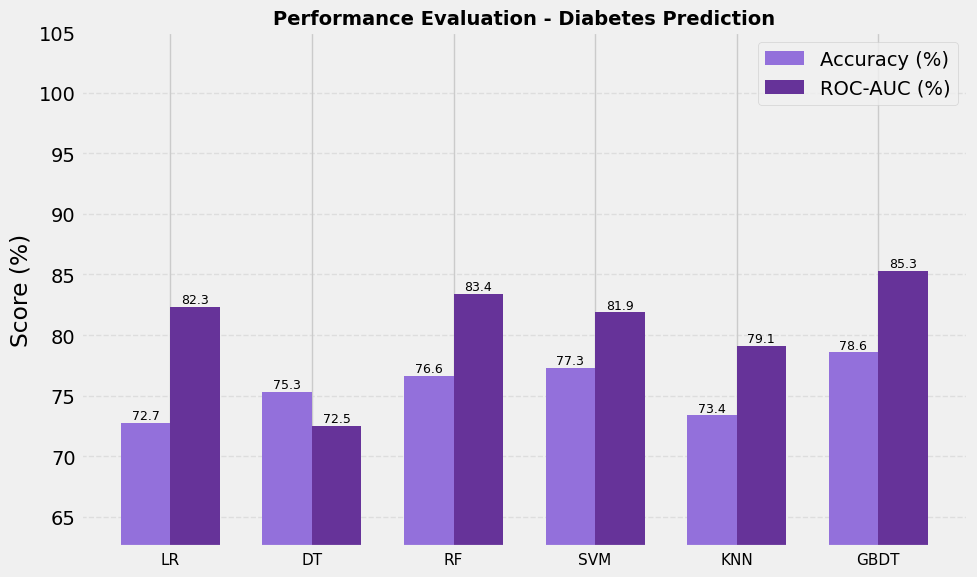

In [86]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

# =====================================================================
# FIX 1: ENSURE 'models' IS A DICTIONARY (Matches your exact short_labels)
# =====================================================================
# If you haven't defined 'models' as a dictionary with these exact string keys, 
# uncomment and use this structure so 'models[label]' works perfectly:

# from sklearn.linear_model import LogisticRegression
# from sklearn.tree import DecisionTreeClassifier
# from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
# from sklearn.svm import SVC
# from sklearn.neighbors import KNeighborsClassifier

# models = {
#     "Logistic Regression": LogisticRegression(max_iter=1000),
#     "Decision Tree": DecisionTreeClassifier(random_state=42),
#     "Random Forest": RandomForestClassifier(random_state=42),
#     "Support Vector Machine": SVC(probability=True, random_state=42),
#     "KNN": KNeighborsClassifier(),
#     "Gradient Boosting": GradientBoostingClassifier(random_state=42)
# }

# =====================================================================
# FIX 2: ENSURE 'results' IS A DATAFRAME
# =====================================================================
# Force conversions to prevent list index errors
if isinstance(results, list):
    results = pd.DataFrame(results)

# FIXED SYNTAX: Using square brackets [] instead of parentheses ()
model_labels = results["Model"].tolist()

means_accuracy = (
    results.set_index("Model")
    .loc[model_labels, "Accuracy"]
    .to_numpy() * 100
)

means_roc = []

# ------------------------------------
# Calculate ROC-AUC Loop
# ------------------------------------
for label in model_labels:
    # This will now work because 'models' is guaranteed to be a dictionary
    model = models[label]

    # Fit the model to ensure it is trained
    model.fit(X_train, y_train)

    if hasattr(model, "predict_proba"):
        y_score = model.predict_proba(X_test)[:, 1]
    elif hasattr(model, "decision_function"):
        y_score = model.decision_function(X_test)
    else:
        means_roc.append(np.nan)
        continue

    fpr, tpr, _ = roc_curve(y_test, y_score)
    means_roc.append(auc(fpr, tpr) * 100)

means_roc = np.array(means_roc)

# ------------------------------------
# Short labels mapping
# ------------------------------------
short_labels = {
    "Logistic Regression": "LR",
    "Decision Tree": "DT",
    "Random Forest": "RF",
    "Support Vector Machine": "SVM",
    "KNN": "KNN",
    "Gradient Boosting": "GBDT",
}

x_labels = [short_labels.get(name, name) for name in model_labels]

# ------------------------------------
# Plotting
# ------------------------------------
fig, ax = plt.subplots(figsize=(10, 6))

index = np.arange(len(model_labels))
bar_width = 0.35

bars1 = ax.bar(index, means_accuracy, width=bar_width, color="mediumpurple", label="Accuracy (%)")
bars2 = ax.bar(index + bar_width, means_roc, width=bar_width, color="rebeccapurple", label="ROC-AUC (%)")

# Add text labels on top of bars safely
for bar in bars1:
    height = bar.get_height()
    if not np.isnan(height):
        ax.text(bar.get_x() + bar.get_width()/2, height + 0.3, f"{height:.1f}", ha="center", fontsize=9)

for bar in bars2:
    height = bar.get_height()
    if not np.isnan(height):
        ax.text(bar.get_x() + bar.get_width()/2, height + 0.3, f"{height:.1f}", ha="center", fontsize=9)

# Formatting chart
ax.set_xticks(index + bar_width / 2)
ax.set_xticklabels(x_labels, fontsize=11)

# Dynamically set ylim based on minimum scores to keep it proportional
all_scores = np.concatenate([means_accuracy, means_roc[~np.isnan(means_roc)]])
min_score = min(all_scores) if len(all_scores) > 0 else 70
ax.set_ylim(max(0, min_score - 10), 105)

ax.set_ylabel("Score (%)")
ax.set_title("Performance Evaluation - Diabetes Prediction", fontsize=14, weight="bold")
ax.legend()
ax.grid(axis="y", linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()
plt.close()

In [87]:
final_result = results.rename(
    columns={
        "Model": "Algorithms",
        "F1": "F1_Score"
    }
)[
    ["Algorithms", "Accuracy", "Recall", "Precision", "F1_Score"]
].copy()

final_result

,Algorithms,Accuracy,Recall,Precision,F1_Score
0,Logistic Regression,0.727273,0.685185,0.596774,0.637931
1,Decision Tree,0.753247,0.629630,0.653846,0.641509
2,Random Forest,0.766234,0.740741,0.645161,0.689655
3,SVM,0.772727,0.814815,0.637681,0.715447
4,KNN,0.733766,0.740741,0.597015,0.661157
5,Gradient Boosting,0.785714,0.777778,0.666667,0.717949


In [88]:
import os

folders = [
    "images",
    "models",
    "results",
    "reports"
]

for folder in folders:
    os.makedirs(folder, exist_ok=True)

print("Folders created successfully.")

Folders created successfully.


##############################################################
# SAVE MODEL
##############################################################

In [89]:
import joblib

random_forest = models["Random Forest"]
logistic_model = models["Logistic Regression"]
svm_model = models["SVM"]

joblib.dump(
    random_forest,
    "models/RandomForest.pkl"
)

joblib.dump(
    logistic_model,
    "models/LogisticRegression.pkl"
)

joblib.dump(
    svm_model,
    "models/SVM.pkl"
)

joblib.dump(
    best,
    "models/Best_Model.pkl"
)

['models/Best_Model.pkl']

##############################################################
## SAVE RESULTS
##############################################################

In [90]:
results.to_csv(

    "Model_Comparison.csv",

    index=False

)

importance.to_csv(

    "Feature_Importance.csv",

    index=False

)

print("Results Saved.")


Results Saved.


## Save the Classification Report

In [110]:

pred = best.predict(X_test)
report = classification_report(y_test, pred)

with open(
    "results/classification_report.txt",
    "w"
) as f:
    f.write(report)

with open(
    "results/classification_report.txt",
    "w"
) as f:

    f.write(report)

## Finam Summary

In [112]:
accuracy = accuracy_score(y_test, pred)
precision = precision_score(y_test, pred)
recall = recall_score(y_test, pred)
f1 = f1_score(y_test, pred)
roc_auc = roc  # uses previously computed AUC for `best`

summary = pd.DataFrame({

    "Best Model":[best.__class__.__name__],

    "Accuracy":[accuracy],

    "Precision":[precision],

    "Recall":[recall],

    "F1":[f1],

    "ROC-AUC":[roc_auc]

})

summary.to_csv(
    "results/final_summary.csv",
    index=False
)